# Library import

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
# ===============================
# 1️⃣ Setup library import
# ===============================
# Get the repository root (assuming the notebook is inside "notebooks/")
repo_root = Path().resolve().parent  # notebooks/ -> Library development
sys.path.append(str(repo_root))      # add repo root to sys.path

In [3]:
import data_analysis_pro_plotting as dap

In [4]:
# ===============================
# 2️⃣ Setup dataset paths
# ===============================
data_dir = repo_root / "data"  # "data" folder at the root of the repo

In [5]:
file_path = data_dir / "df_anonymized_vst.csv"

In [6]:
df_example=pd.read_csv(file_path)

In [7]:
df_example

,gene_id,count_1,count_2,count_4,count_5,count_6,count_7,count_8,gene_name
0,ENSMUSG00000036099,8.349896,8.285862,8.861076,8.703338,8.195218,8.606585,8.204011,Vezt
1,ENSMUSG00000029651,4.830974,5.412666,5.419785,4.721646,4.752332,5.254819,5.300439,Mtus2
2,ENSMUSG00000026017,6.918318,7.472383,7.022067,6.013045,7.053658,6.657265,7.564424,Carf
3,ENSMUSG00000069727,7.999130,7.036917,7.127998,6.939462,6.648426,7.032293,5.682625,Gm5595
4,ENSMUSG00000042015,8.289448,8.625378,9.364119,9.314680,9.370484,10.442493,10.131258,Wdr41
...,...,...,...,...,...,...,...,...,...
195,ENSMUSG00000043154,7.159718,7.443176,7.397462,8.936233,6.742886,7.826613,7.473570,Ppp2r3a
196,ENSMUSG00000070291,5.797628,6.720510,5.861055,5.480130,4.635777,4.982390,5.409657,Ddx43
197,ENSMUSG00000024317,8.652312,9.452564,9.188236,8.364011,7.807166,9.155452,7.879640,Rnf138
198,ENSMUSG00000097901,3.805138,4.996070,4.070311,3.688461,4.863412,4.680374,3.823481,Gm26680


# PCA

In [11]:
df_example_drop = df_example.drop(['gene_id', 'gene_name'], axis=1)

In [12]:
treatments = ['Treatment_1']*2 + ['Treatment_2']*2 + ['Treatment_3']*3

In [13]:
pca_df, pca = dap.calculate_pca(
    df_example_drop,
    treatments= treatments,
    exclude_treatments=None,
    exclude_samples=None,
    n_components=2
)

In [14]:
pca_df

,PC1,PC2,Treatment,Sample
0,5.600244,-3.729154,Treatment_1,count_1
1,6.298219,-3.875562,Treatment_1,count_2
2,-5.696540,-4.069737,Treatment_2,count_4
3,-6.835609,-2.913821,Treatment_2,count_5
4,0.241283,5.222060,Treatment_3,count_6
5,1.078357,4.169871,Treatment_3,count_7
6,-0.685955,5.196343,Treatment_3,count_8


In [15]:
markers = {
    "Treatment_1": "o",  
    "Treatment_2": "s",    
    "Treatment_3": "^"     
}

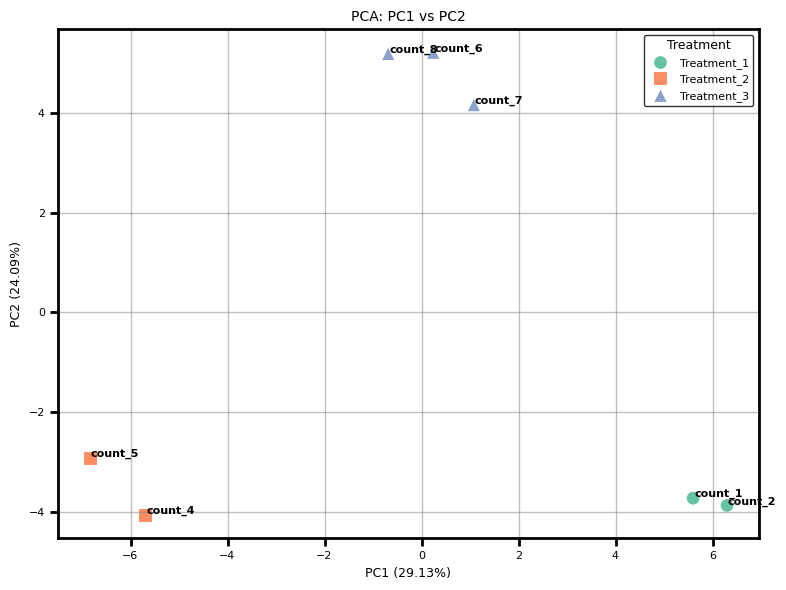

In [17]:
dap.plot_pca(
    # =========================
    # PCA data
    # =========================
    pca_df,
    pca= pca,
    pc_x=1,
    pc_y=2,
    group_col='Treatment',

    # =========================
    # Dot style
    # =========================
    palette="Set2",
    point_size=100,
    label_samples=True,
    label_offset=(0.02, 0.02),
    fontsize_points=8,
    fontweight_points="bold",
    rename_samples=None,  
    markers=markers,
    alpha=1,
    
    # =========================
    # Axis labels
    # =========================
    xlabel=None,
    ylabel=None,
    show_xlabel=True,
    show_ylabel=True,
    fontsize_labels=9,
    fontweight_labels="normal",
    

    # =========================
    # title
    # =========================
    title=None,
    show_title=True,
    fontsize_title=10,
    fontweight_title="normal",

    # =========================
    # Legend
    # =========================
    show_legend=True,
    legend_title=None,
    legend_loc="upper right",
    legend_frame=True,       
    legend_facecolor="white",
    legend_edgecolor="black",
    legend_edgewidth=1,
    legend_alpha=1.0,
    fontsize_legend=8,
    fontsize_legend_title=9,
    fontweight_legend="normal",
    fontweight_legend_title="normal",

    # =========================
    # Ticks
    # =========================
    show_xticks=True,
    show_yticks=True,
    fontsize_ticks=8,
    tick_width=2,
    tick_length=6,
    fontweight_ticks="normal",

    # =========================
    # Spines (frame)
    # =========================
    show_spines=True,
    spine_width=2,

    # =========================
    # Grid
    # =========================
    grid=True,
    grid_color="grey",
    grid_alpha=0.5,
    grid_width=1,

    # =========================
    # Figure and export
    # =========================
    figsize=(8, 6),
    dpi=600,
    save_path=None,
    
    # -------------------------
    # Optional return
    # -------------------------
    return_fig=False
)

In [18]:
top_PC1, top_PC2 = dap.obtain_top_variables(
    pca=pca,
    filtered_data=df_example_drop,
    metadata_df= df_example,
    name_column='gene_name',
    top_n=20,
    n_pcs=2
)

In [19]:
top_PC1

,gene_name,PC1
182,Dusp6,0.298184
118,Zc3h12c,-0.266825
194,Nat8l,0.244802
76,Zc3h12a,-0.214848
183,Gfi1b,-0.214291
177,Tcf24,0.193820
95,Gm10521,0.163743
44,Sspn,0.152929
141,Wwp1,0.152526
29,Ino80d,-0.144820


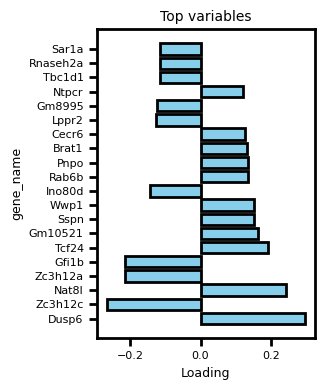

In [20]:
dap.plot_top_variables_pc(
    # =========================
    # Data
    # =========================
    top_PC1,
    pc_col='PC1',
    name_column='gene_name',
    pc_num=None,  

    # =========================
    # Bar style
    # =========================
    bar_color="skyblue",
    bar_edgecolor="black",
    bar_edge_width=2,

    # =========================
    # Title
    # =========================
    title=None,
    show_title=True,
    fontsize_title=10,
    fontweight_title="normal",

    # =========================
    # Axis labels
    # =========================
    xlabel=None,
    show_xlabel=True,
    ylabel=None,
    show_ylabel=True,
    fontsize_label=9,
    fontweight_label="normal",

    # =========================
    # Ticks
    # =========================
    show_xticks=True,
    show_yticks=True,
    fontsize_ticks=8,
    fontweight_ticks="normal",
    tick_width=2,
    tick_length=6,

    # =========================
    # Spines
    # =========================
    spine_width=2,

    # =========================
    # Figure and export
    # =========================
    figsize=(3.35, 4),
    dpi=600,
    save_path=None
)

In [21]:
top_PC2

,gene_name,PC2
170,Gm8995,0.277708
182,Dusp6,0.207400
166,Zfp704,-0.181438
183,Gfi1b,-0.180876
88,Tmc7,-0.163524
141,Wwp1,-0.158706
121,Tmco4,0.155712
95,Gm10521,-0.150038
77,Chchd10,0.149738
29,Ino80d,0.133667


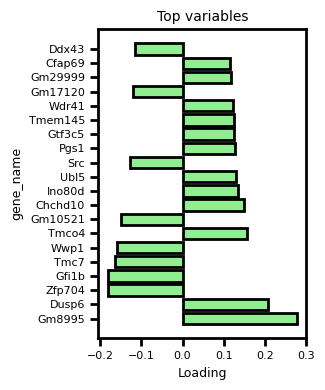

In [22]:
dap.plot_top_variables_pc(
    # =========================
    # Data
    # =========================
    top_PC2,
    pc_col='PC2',
    name_column='gene_name',
    pc_num=None,  

    # =========================
    # Bar style
    # =========================
    bar_color="lightgreen",
    bar_edgecolor="black",
    bar_edge_width=2,

    # =========================
    # Title
    # =========================
    title=None,
    show_title=True,
    fontsize_title=10,
    fontweight_title="normal",

    # =========================
    # Axis labels
    # =========================
    xlabel=None,
    show_xlabel=True,
    ylabel=None,
    show_ylabel=True,
    fontsize_label=9,
    fontweight_label="normal",

    # =========================
    # Ticks
    # =========================
    show_xticks=True,
    show_yticks=True,
    fontsize_ticks=8,
    fontweight_ticks="normal",
    tick_width=2,
    tick_length=6,

    # =========================
    # Spines
    # =========================
    spine_width=2,

    # =========================
    # Figure and export
    # =========================
    figsize=(3.35, 4),
    dpi=600,
    save_path=None
)

# Distance heatmap

In [23]:
dis_matrix = dap.calculate_distance_matrix(df_example_drop, distance_metric="euclidean")

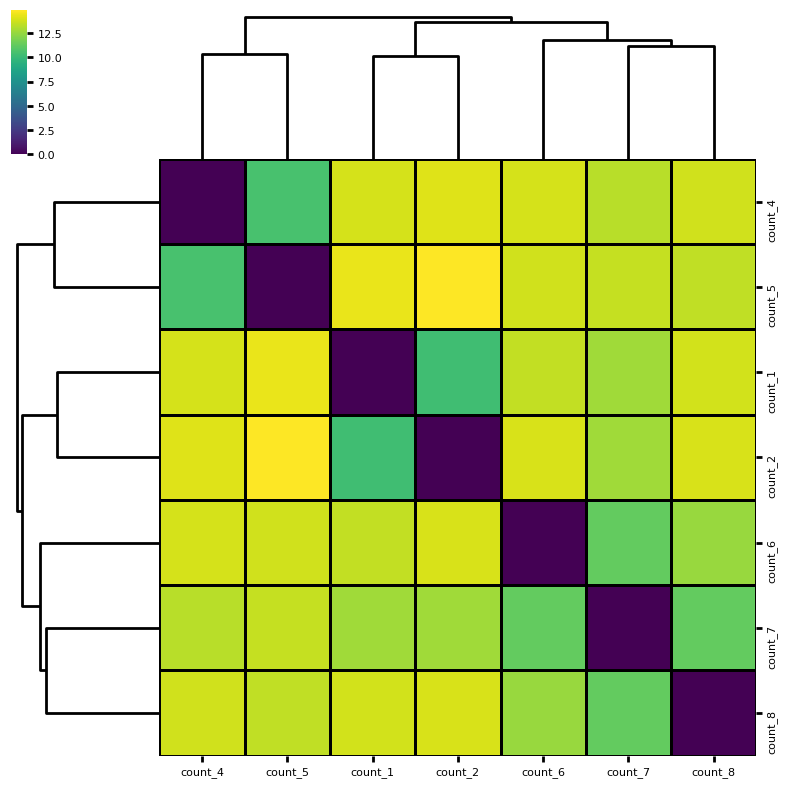

In [24]:
dap.plot_distance_heatmap(
    # =========================
    # Data
    # =========================
    dist_df=dis_matrix ,

    # =========================
    # Heatmap 
    # =========================
    cmap="viridis",
    cell_linewidth=2,
    cell_linecolor="black",

    # =========================
    # Title
    # =========================
    show_title=False,
    title=None,
    fontsize_title=10,
    fontweight_title="normal",

    # =========================
    # Axis labels
    # =========================
    show_xlabel=False,
    show_ylabel=False,
    xlabel=None,
    ylabel=None,
    fontsize_labels=9,
    fontweight_labels="normal",

    # =========================
    # Ticks (heatmap)
    # =========================
    show_xticks=True,
    show_yticks=True,
    xtick_labels_map=None,
    ytick_labels_map=None,
    fontsize_ticks=8,
    fontweight_ticks="normal",
    tick_width=2,
    tick_length=4,
    xtick_label_rotation=None,
    ytick_label_rotation=None,
    
    # =========================
    # Spines (heatmap)
    # =========================
    spine_width=2,

    # =========================
    # Dendrograms
    # =========================
    show_row_dendrogram=True,
    show_col_dendrogram=True,
    dendrogram_linewidth=2,
    dendrogram_color="black",

    # =========================
    # Colorbar
    # =========================
    show_colorbar=True,
    cbar_label=None,
    cbar_left=0.02,
    cbar_bottom=0.8,
    cbar_width=0.02,
    cbar_height=0.18,
    cbar_tick_size=8,
    cbar_tick_width=2,
    cbar_tick_length=4,
    fontweight_cbar_ticks="normal",
    cbar_label_size=9,
    fontweight_cbar_label="normal",
    cbar_show_spines=False,
    cbar_spine_width=2,

    # =========================
    # Figure and export
    # =========================
    figsize=(8, 8),
    dpi=300,
    save_path=None
)

# Hierarchical Heatmap

In [25]:
df_hierarc_heatmap = df_example.set_index('gene_name').drop(['gene_id','count_6'], axis=1)
df_hierarc_heatmap

,count_1,count_2,count_4,count_5,count_7,count_8
gene_name,,,,,,
Vezt,8.349896,8.285862,8.861076,8.703338,8.606585,8.204011
Mtus2,4.830974,5.412666,5.419785,4.721646,5.254819,5.300439
Carf,6.918318,7.472383,7.022067,6.013045,6.657265,7.564424
Gm5595,7.999130,7.036917,7.127998,6.939462,7.032293,5.682625
Wdr41,8.289448,8.625378,9.364119,9.314680,10.442493,10.131258
...,...,...,...,...,...,...
Ppp2r3a,7.159718,7.443176,7.397462,8.936233,7.826613,7.473570
Ddx43,5.797628,6.720510,5.861055,5.480130,4.982390,5.409657
Rnf138,8.652312,9.452564,9.188236,8.364011,9.155452,7.879640


In [26]:
hierarc_matrix = dap.hierarchical_heatmap_matrix(df_hierarc_heatmap, scale="zscore")

In [27]:
gene_list=['Sar1a','Tmc7']

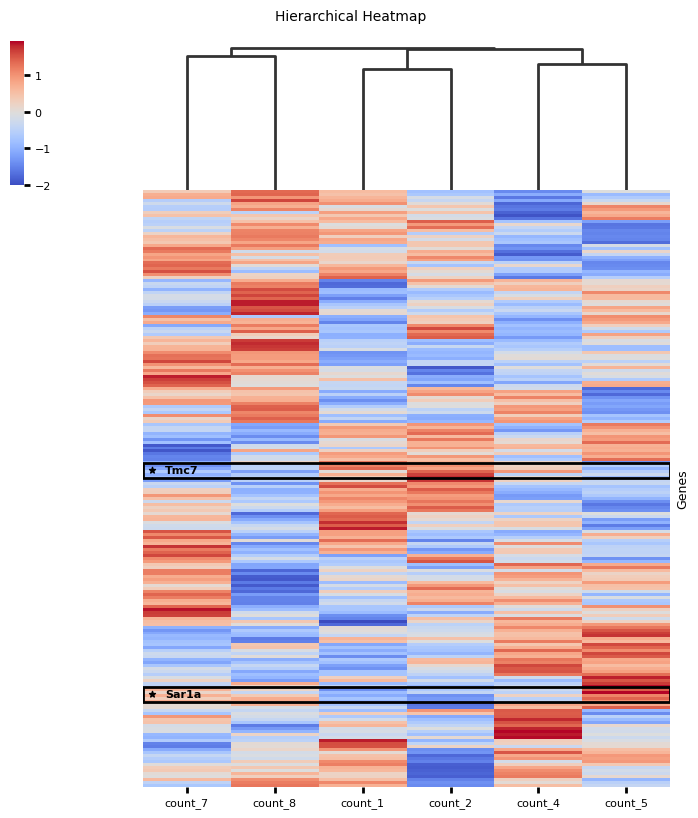

In [28]:
dap.plot_hierarchical_heatmap_highlighted_genes (
    # =========================
    # Data
    # =========================
    df_plot= hierarc_matrix ,

    # =========================
    # Heatmap
    # =========================
    cmap="coolwarm",
    center=None,
    clustering_method="euclidean",
    linkage_method="average",
    cell_linewidth=0,

    # ===========================
    # Clustering and dendogram
    # ===========================
    row_cluster=True,
    col_cluster=True,
    show_row_dendrogram=False,
    show_col_dendrogram=True,
    dendrogram_linewidth=2,
    
    # =========================
    # Labels (ticks)
    # =========================
    show_xtick_labels=True,
    xtick_label_map=None,
    show_ytick_labels=False,
    fontsize_samples=8,
    fontsize_genes=6,
    max_yticks=100,
    fontweight_samples="normal",
    fontweight_genes="normal",
    tick_width=2,
    tick_length=4,
    xtick_label_rotation=0,
    
    # =========================
    # Axis labels
    # =========================
    xlabel=None,
    ylabel=None,
    show_xlabel=False,
    show_ylabel=True,
    fontsize_axis_labels=9,
    fontweight_axis_labels="normal",

    # =========================
    # Title
    # =========================
    title=None,
    show_title=True,
    fontsize_title=10,
    fontweight_title="normal",   

    # =========================
    # Colorbar
    # =========================
    show_colorbar=True,
    cbar_left=0.02,
    cbar_bottom=0.8,
    cbar_width=0.02,
    cbar_height=0.18,
    cbar_tick_size=8,
    cbar_tick_width=2,
    cbar_tick_length=4,
    cbar_label=None,
    cbar_label_size=9,
    fontweight_cbar_ticks="normal",
    fontweight_cbar_label="normal",
    cbar_show_spines=False,
    cbar_spine_width=2,
    
    # =========================
    # Highlighted genes
    # =========================
    highlighted_genes=gene_list,
    marker_show=True,
    marker_color="black",
    marker_style="*",
    marker_size=20,
    marker_xpos=0.10,
    label_color="black",
    label_fontsize=8,
    label_fontweight="bold",
    label_fontstyle="normal",   # normal, italic, oblique
    label_xpos=0.25,
    label_ypos=None,

    # =========================
    # Highlighted rectangle
    # =========================
    highlight_rect=True,
    rect_color="black",
    rect_linewidth=2,
    rect_height=5.0,

    # =========================
    # Figure saving and export
    # =========================
    figsize=(7.09, 8),
    dpi=600,
    save_path=None
 
)

# Dendograms

In [29]:
Z, labels= dap.calculate_samples_dendogram(
    df_vst= df_example_drop ,
    distance_method="euclidean",
    linkage_method="average",
    scale_by_gene=False
)

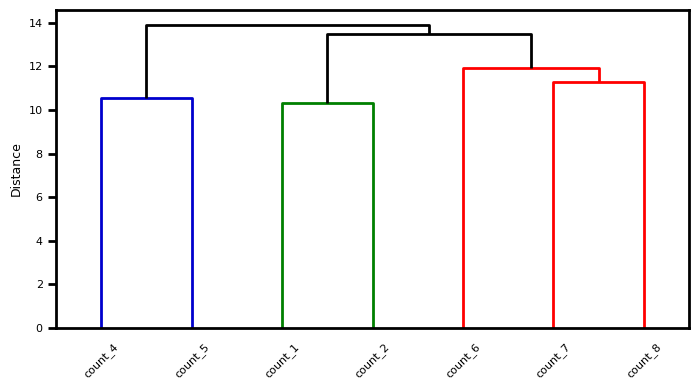

In [30]:
dap.plot_samples_dendogram(
    # =========================
    # Data
    # =========================
    Z= Z,
    labels= labels,

    # =========================
    # Leaf renaming
    # =========================
    rename_dict=None,

    # =========================
    # Dendogram
    # =========================
    orientation="top",
    leaf_rotation=90,
    dendrogram_linewidth=2,
    
    # =========================
    # Cluster thresholding
    # =========================
    color_threshold=None,   
    n_clusters=3,        
    
    # =========================
    # Colors
    # =========================
    mode_color="custom",          
    cluster_palette=['mediumblue','green','red'],       
    above_threshold_color="black",

    # =========================
    # Title
    # =========================
    show_title=False,
    title=None,
    fontsize_title=10,
    fontweight_title="bold",

    # =========================
    # Axis labels
    # =========================
    show_ylabel=True,
    show_xlabel=False,
    ylabel="Distance",
    xlabel=None,
    fontsize_labels=9,
    fontweight_ylabel="normal",
    fontweight_xlabel="normal",

    # =========================
    # Ticks
    # =========================
    fontsize_ticks=8,
    fontweight_ticks="normal",
    tick_width=2,
    tick_length=6,
    xtick_label_rotation=45,

    # =========================
    # Spines
    # =========================
    show_spines=True,
    spine_width=2,

    # =========================
    # Figure saving and export
    # =========================
    figsize=(7.09, 4),
    dpi=600,
    save_path=None
)

# Venn diagram

In [31]:
file_path = data_dir / "df_sigs1_simulated.csv"

In [34]:
df_sigs1_simulated =pd.read_csv(file_path)

In [35]:
df_sigs1_simulated

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name
0,ENSMUSG00000038147,9098.722487,-1.863150,0.351632,-14.665158,5.148162e-50,3.930533e-48,Cd84
1,ENSMUSG00000030844,2552.837669,-2.377024,0.468304,-13.906781,1.011565e-47,8.941237e-46,Rgs10
2,ENSMUSG00000070462,1033.303485,1.353728,-0.092856,7.630066,1.474314e-14,2.721615e-13,Mesdc1
3,ENSMUSG00000021806,191.272224,-3.700309,0.062924,-8.915571,4.703881e-19,9.264176e-18,Nid2
4,ENSMUSG00000026170,130.751811,-3.170833,0.721307,-7.787645,4.462219e-13,7.852550e-12,Cyp27a1
...,...,...,...,...,...,...,...,...
195,ENSMUSG00000027566,2475.507713,0.603589,0.428613,5.899922,4.907563e-09,5.236341e-08,Psma7
196,ENSMUSG00000016529,95.891711,8.213787,1.390322,6.640062,1.520363e-14,2.900117e-13,Il10
197,ENSMUSG00000031851,571.370895,-1.484476,0.398979,-6.677680,4.088486e-13,3.865251e-12,Ntpcr
198,ENSMUSG00000052485,41.256522,1.026234,0.409677,2.689977,2.200203e-03,8.490913e-03,Tmem171


In [36]:
file_path = data_dir / "df_sigs2_simulated.csv"

In [37]:
df_sigs2_simulated=pd.read_csv(file_path)

In [38]:
df_sigs2_simulated

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name
0,ENSMUSG00000043633,3563.770525,0.980946,0.323246,4.915297,1.018143e-05,8.634576e-05,Fam221b
1,ENSMUSG00000020412,784.538848,0.065276,0.091058,2.685586,2.087688e-03,7.252328e-03,Ascc2
2,ENSMUSG00000025207,94.656058,-3.364406,0.014111,-8.471279,1.031179e-16,1.528556e-15,Sema4g
3,ENSMUSG00000018427,51.415915,-2.566939,0.439117,-6.881793,8.267830e-11,1.124956e-09,Ypel2
4,ENSMUSG00000033871,32.174929,3.625764,-0.119430,4.754935,2.334367e-07,2.565541e-06,Ppargc1b
...,...,...,...,...,...,...,...,...
195,ENSMUSG00000028088,80.643659,-2.257692,0.180844,-4.095130,8.504093e-05,3.758793e-04,Fmo5
196,ENSMUSG00000022437,1110.838189,0.653058,0.118534,5.575946,1.045385e-07,7.581946e-07,Samm50
197,ENSMUSG00000031948,1369.069680,0.836267,-0.484961,9.579214,5.682651e-24,1.725170e-22,Kars
198,ENSMUSG00000041112,2066.343547,-1.153625,-0.267523,-9.098697,3.365723e-17,6.998947e-16,Elmo1


In [39]:
# upregulated genes of set 1
up_genes_set1 = df_sigs1_simulated[
    (df_sigs1_simulated["log2FoldChange"] > 0) &
    (df_sigs1_simulated["padj"] < 0.05)
].index.tolist()

In [40]:
# upregulated genes of set 2
up_genes_set2 = df_sigs2_simulated[
    (df_sigs2_simulated["log2FoldChange"] > 0) &
    (df_sigs2_simulated["padj"] < 0.05)
].index.tolist()

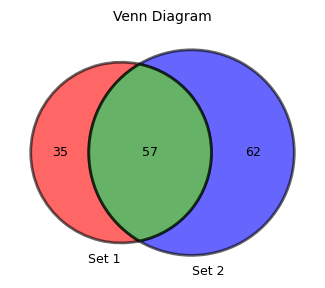

In [41]:
dap.plot_venn2(
    # =========================
    # Data
    # =========================
    set1= up_genes_set1,
    set2=up_genes_set2,

    # =========================
    # Labels
    # =========================
    labels=("Set 1", "Set 2"),
    show_labels=True,
    font_size=9,
    label_fontweight="normal",
    label_fontstyle="normal",

    # =========================
    # Title
    # =========================
    title=None,
    show_title=True,
    fontsize_title=10,
    title_fontweight="normal",
    title_fontstyle="normal",

    # =========================
    # Venn diagram aesthetics
    # =========================
    colors= ('red', 'blue'),
    intersection_color= 'green',
    dibujar_bordes=True,
    line_width=2,
    alpha=0.6,

    # =========================
    # Axes
    # =========================
    show_axes=False,
    show_spines=False,
    spine_width=2,

    # =========================
    # Figure saving and export
    # =========================
    figsize=(3.35, 3.35),
    dpi=600,
    save_path=None
)

In [42]:
# downregulated genes of set 1
down_genes_set1 = df_sigs1_simulated[
    (df_sigs1_simulated["log2FoldChange"] < 0) &
    (df_sigs1_simulated["padj"] < 0.05)
].index.tolist()

In [43]:
# downregulated genes of set 2
down_genes_set2 = df_sigs2_simulated[
    (df_sigs2_simulated["log2FoldChange"] < 0) &
    (df_sigs2_simulated["padj"] < 0.05)
].index.tolist()

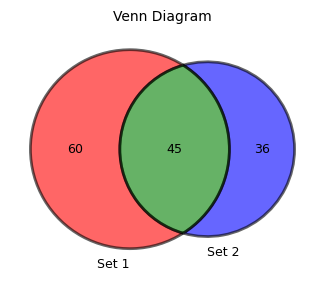

In [44]:
dap.plot_venn2(
    # =========================
    # Data
    # =========================
    set1= down_genes_set1,
    set2= down_genes_set2,

    # =========================
    # Labels
    # =========================
    labels=("Set 1", "Set 2"),
    show_labels=True,
    font_size=9,
    label_fontweight="normal",
    label_fontstyle="normal",

    # =========================
    # Title
    # =========================
    title=None,
    show_title=True,
    fontsize_title=10,
    title_fontweight="normal",
    title_fontstyle="normal",

    # =========================
    # Venn diagram aesthetics
    # =========================
    colors= ('red', 'blue'),
    intersection_color= 'green',
    dibujar_bordes=True,
    line_width=2,
    alpha=0.6,

    # =========================
    # Axes
    # =========================
    show_axes=False,
    show_spines=False,
    spine_width=2,

    # =========================
    # Figure saving and export
    # =========================
    figsize=(3.35, 3.35),
    dpi=600,
    save_path=None
)

# Volcano plot

In [45]:
file_path = data_dir / "df_simulated_stats.csv"

In [46]:
df_simulated_stats=pd.read_csv(file_path)
df_simulated_stats

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name
0,ENSMUSG00000053684,159.237023,0.321897,1.093331,0.553560,9.116800e-01,9.776060e-01,BC048403
1,ENSMUSG00000044496,1891.411359,0.814080,-0.446534,5.731146,1.021808e-07,8.130455e-07,2510039O18Rik
2,ENSMUSG00000039316,644.740938,-0.263748,0.925138,-2.467918,1.647667e-02,4.072166e-02,Rftn1
3,ENSMUSG00000055204,1807.386292,0.424561,1.359567,3.529603,1.715827e-03,8.123737e-03,Ankrd17
4,ENSMUSG00000003665,22.695396,5.350060,0.692731,4.739573,1.793681e-06,1.287525e-05,Has1
...,...,...,...,...,...,...,...,...
195,ENSMUSG00000048920,557.048006,-0.072621,-0.317932,0.862833,1.055849e-01,1.979654e-01,Fkrp
196,ENSMUSG00000022571,275.623889,0.350747,0.198077,1.816658,1.227611e-01,2.436004e-01,Pycrl
197,ENSMUSG00000086740,15.139646,-0.740291,0.688276,-1.451162,4.466557e-01,7.658507e-01,Gm17029
198,ENSMUSG00000026646,51.693749,2.175799,-0.225939,2.325381,9.068016e-03,3.715234e-02,Suv39h2


In [47]:
df_volcano = df_simulated_stats.copy()

df_volcano["padj"] = df_volcano["padj"].fillna(1)

df_volcano["significance"] = "NS"

df_volcano.loc[
    (df_volcano["log2FoldChange"] > 0.5) &
    (df_volcano["padj"] < 0.05),
    "significance"
] = "Up"

df_volcano.loc[
    (df_volcano["log2FoldChange"] < -0.5) &
    (df_volcano["padj"] < 0.05),
    "significance"
] = "Down"

In [48]:
df_volcano["significance"].value_counts()

significance
NS      140
Up       30
Down     30
Name: count, dtype: int64

In [49]:
df_volcano

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,significance
0,ENSMUSG00000053684,159.237023,0.321897,1.093331,0.553560,9.116800e-01,9.776060e-01,BC048403,NS
1,ENSMUSG00000044496,1891.411359,0.814080,-0.446534,5.731146,1.021808e-07,8.130455e-07,2510039O18Rik,Up
2,ENSMUSG00000039316,644.740938,-0.263748,0.925138,-2.467918,1.647667e-02,4.072166e-02,Rftn1,NS
3,ENSMUSG00000055204,1807.386292,0.424561,1.359567,3.529603,1.715827e-03,8.123737e-03,Ankrd17,NS
4,ENSMUSG00000003665,22.695396,5.350060,0.692731,4.739573,1.793681e-06,1.287525e-05,Has1,Up
...,...,...,...,...,...,...,...,...,...
195,ENSMUSG00000048920,557.048006,-0.072621,-0.317932,0.862833,1.055849e-01,1.979654e-01,Fkrp,NS
196,ENSMUSG00000022571,275.623889,0.350747,0.198077,1.816658,1.227611e-01,2.436004e-01,Pycrl,NS
197,ENSMUSG00000086740,15.139646,-0.740291,0.688276,-1.451162,4.466557e-01,7.658507e-01,Gm17029,NS
198,ENSMUSG00000026646,51.693749,2.175799,-0.225939,2.325381,9.068016e-03,3.715234e-02,Suv39h2,Up


In [50]:
df_volcano["minus_log10_padj"] = -np.log10(df_volcano["padj"])

In [51]:
(df_volcano["padj"] == 0).sum()

np.int64(0)

In [52]:
(df_volcano["padj"] < 0).sum()

np.int64(0)

In [53]:
df_up_sorted = df_volcano[df_volcano["significance"] == "Up"] \
                  .sort_values(by="minus_log10_padj", ascending=False)
df_up_sorted

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,significance,minus_log10_padj
108,ENSMUSG00000030830,13916.737899,2.090118,0.963890,17.323605,3.739576e-74,4.874975e-72,Itgal,Up,71.312028
76,ENSMUSG00000025017,5149.169332,2.765026,1.265622,15.383156,8.667897e-56,6.892712e-54,Pik3ap1,Up,53.161610
5,ENSMUSG00000076617,135.787138,4.439992,0.756627,7.846372,4.200189e-17,7.269261e-16,Ighm,Up,15.138510
107,ENSMUSG00000002718,1372.604561,1.188028,0.630581,7.878194,1.219447e-15,1.961399e-14,Cse1l,Up,13.707434
104,ENSMUSG00000049719,48.033942,4.228658,0.571108,6.303777,6.548231e-12,5.740736e-11,Prss46,Up,10.241032
65,ENSMUSG00000040964,100.035277,2.970776,0.551139,6.636446,1.735807e-11,1.794633e-10,Arhgef10l,Up,9.746024
100,ENSMUSG00000026421,1107.465525,1.179455,-0.584567,6.516618,1.803761e-11,1.861583e-10,Csrp1,Up,9.730118
86,ENSMUSG00000027959,154.276654,1.485174,0.663015,4.980059,1.836687e-08,1.850769e-07,Sass6,Up,6.732648
1,ENSMUSG00000044496,1891.411359,0.814080,-0.446534,5.731146,1.021808e-07,8.130455e-07,2510039O18Rik,Up,6.089885
180,ENSMUSG00000062867,298.482997,2.017243,-0.763776,6.003271,2.609504e-07,1.897506e-06,Impdh2,Up,5.721817


In [54]:
df_down_sorted = df_volcano[df_volcano["significance"] == "Down"] \
                  .sort_values(by="minus_log10_padj", ascending=False)
df_down_sorted

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,significance,minus_log10_padj
69,ENSMUSG00000034563,1006.854899,-0.940924,-0.746886,-16.050441,1.672217e-50,1.216050e-48,Ccpg1,Down,47.915048
96,ENSMUSG00000006932,11605.203149,-1.460899,-1.097652,-15.010712,3.092833e-48,1.831114e-46,Ctnnb1,Down,45.737285
82,ENSMUSG00000026749,2305.520193,-1.846419,0.160582,-11.666409,7.594719e-31,3.559040e-29,Nek6,Down,28.448667
121,ENSMUSG00000017417,1564.006127,-1.597809,-0.027401,-10.461457,1.818690e-23,4.786720e-22,Plxdc1,Down,21.319962
43,ENSMUSG00000006731,1965.460566,-1.096001,-0.453948,-9.062502,8.217881e-20,1.686945e-18,B4galnt1,Down,17.772899
38,ENSMUSG00000021947,1108.212592,-1.253352,-0.614017,-9.377234,1.773391e-19,3.000179e-18,Cryl1,Down,17.522853
70,ENSMUSG00000035105,2549.662310,-1.545249,-0.361879,-8.292016,1.534307e-18,3.674510e-17,Egln3,Down,16.434801
91,ENSMUSG00000023328,126.790678,-2.538753,-0.508898,-7.230983,1.788468e-11,1.776789e-10,Ache,Down,9.750364
178,ENSMUSG00000025612,1421.694280,-0.782869,0.072960,-6.302889,3.948723e-11,5.898561e-10,Bach1,Down,9.229254
46,ENSMUSG00000020262,386.735858,-1.593448,0.515828,-7.161104,1.240979e-10,1.230739e-09,Adarb1,Down,8.909834


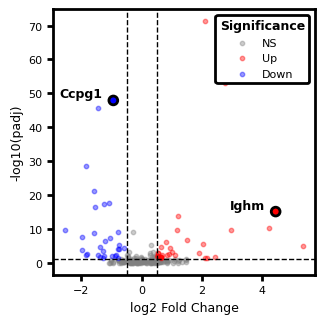

In [58]:
dap.plot_volcano_highlighted_genes(
    # =========================
    # Data
    # =========================
    df=df_volcano ,
    x="log2FoldChange",
    y="minus_log10_padj",
    significance_col="significance",
    gene_col="gene_name",            

    # =========================
    # Groups ans colors
    # =========================
    palette={"NS": "gray", "Up": "red", "Down": "blue"},
    point_size=10,
    alpha=0.4,

    # =========================
    # Cut lines
    # =========================
    fc_threshold=0.5,
    pval_threshold=0.05,
    cut_linewidth=1,
    cut_linestyle="--",

    # =========================
    # Axis labels
    # =========================
    xlabel="log2 Fold Change",
    ylabel="-log10(padj)",
    show_axis_labels=True,
    fontsize_labels=9,
    fontweight_xlabel="normal",
    fontweight_ylabel="normal",

    # =========================
    # Title
    # =========================
    title=None,
    show_title=True,
    fontsize_title=10,
    fontweight_title="bold",

    # =========================
    # Legend
    # =========================
    show_legend=True,
    legend_title="Significance",
    fontsize_legend=8,
    fontsize_legend_title=9,
    fontweight_legend_title="bold",
    fontweight_legend_labels="normal",
    fontstyle_legend_title="normal",     
    fontstyle_legend_labels="normal",
    legend_loc="upper right",
    legend_frame=True,
    legend_edgecolor="black",
    legend_linewidth=2,
    legend_facecolor="white",
    legend_alpha=1,

    # =========================
    # Ticks
    # =========================
    show_ticks=True,
    tick_width=2,
    tick_length=4,
    fontsize_ticks=8,
    fontweight_xticks="normal",
    fontweight_yticks="normal",

    # =========================
    # Spines
    # =========================
    show_spines=True,
    spine_width=2,

    # =========================
    # Y limits
    # =========================
    ylim=None,   # (ymin, ymax) o None para automático

    # =========================
    # Highlight genes
    # =========================
    highlight_genes=['Ighm', 'Ccpg1'],	
    highlight_color=['red','blue'],
    highlight_size=40,
    highlight_edge=True,
    highlight_edgecolor="black",
    highlight_edgewidth=2,
    show_labels=True,
    highlight_fontweight="bold",
    highlight_fontstyle="normal",
    highlight_labelcolor='black',
    highlight_label_xpos={"Ighm": 4.1, "Ccpg1": -1.3},
    highlight_label_ypos=None,
    highlight_label_ha="right",
    highlight_label_va="bottom",

    # =========================
    # Figure saving and export
    # =========================
    figsize=(3.35, 3.35),
    dpi=600,
    save_path= None)

# GSEA

In [59]:
try:
    import gseapy
    print("gseapy is pre-installed in the environment.")
except ImportError:
    print("gseapy is not pre-installed in the environment.")

gseapy is pre-installed in the environment.


In [60]:
import gseapy as gp
from gseapy.plot import gseaplot

In [61]:
ranking = df_simulated_stats[['stat', 'gene_name']].dropna().sort_values('stat', ascending = False)
ranking

,stat,gene_name
108,17.323605,Itgal
76,15.383156,Pik3ap1
107,7.878194,Cse1l
5,7.846372,Ighm
65,6.636446,Arhgef10l
...,...,...
38,-9.377234,Cryl1
121,-10.461457,Plxdc1
82,-11.666409,Nek6
96,-15.010712,Ctnnb1


In [62]:
ranking['gene_name'] = ranking['gene_name'].str.upper()
ranking

,stat,gene_name
108,17.323605,ITGAL
76,15.383156,PIK3AP1
107,7.878194,CSE1L
5,7.846372,IGHM
65,6.636446,ARHGEF10L
...,...,...
38,-9.377234,CRYL1
121,-10.461457,PLXDC1
82,-11.666409,NEK6
96,-15.010712,CTNNB1


In [63]:
ranking[ranking.duplicated(subset='gene_name', keep=False)]

,stat,gene_name


In [64]:
ranking= ranking.set_index('gene_name')
ranking

,stat
gene_name,
ITGAL,17.323605
PIK3AP1,15.383156
CSE1L,7.878194
IGHM,7.846372
ARHGEF10L,6.636446
...,...
CRYL1,-9.377234
PLXDC1,-10.461457
NEK6,-11.666409


In [65]:
mouse = gp.get_library_name(organism='Mouse')
mouse

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'Carcinogenome',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popul

In [66]:
res_gsea = gp.prerank(
    rnk=ranking['stat'],
    gene_sets='KEGG_2019_Mouse',
    seed=6,
    permutation_num=1000,
    min_size=5,
    max_size=1000
)

In [67]:
out = []

for term in list(res_gsea.results):
    out.append([term,
               res_gsea.results[term]['fdr'],
               res_gsea.results[term]['es'],
               res_gsea.results[term]['nes']])

out_df = pd.DataFrame(out, columns = ['Term','fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)
out_df

,Term,fdr,es,nes
0,Pathways in cancer,0.015534,-0.804085,-1.637802
1,Human papillomavirus infection,0.123625,-0.688557,-1.373653
2,Human T-cell leukemia virus 1 infection,0.223368,0.655610,1.268917


In [68]:
res = res_gsea.results['Pathways in cancer']

In [69]:
genes_pathway = res["matched_genes"]
genes_pathway

'GRB2;EGFR;GADD45A;CREBBP;ETS1;EGLN3;CTNNB1'

In [70]:
gene_styles = {
    "GRB2": {
        "line_color": "red",
        "line_style": "-",
        "line_width": 2,
        "text_color": "red"
    },
    "EGFR": {
        "line_color": "blue",
        "line_style": "--",
        "line_width": 2,
        "text_color": "blue"
    },
    "GADD45A": {
        "line_color": "green",
        "line_style": "-.",
        "line_width": 2,
        "text_color": "green"
    },
    "CREBBP": {
        "line_color": "purple",
        "line_style": ":",
        "line_width": 2,
        "text_color": "purple"
    },
    "ETS1": {
        "line_color": "orange",
        "line_style": (0, (3,1,1,1)),
        "line_width": 2,
        "text_color": "orange"
    }
}

In [71]:
path_genes= ['GRB2', 'EGFR', 'GADD45A', 'CREBBP', 'ETS1']

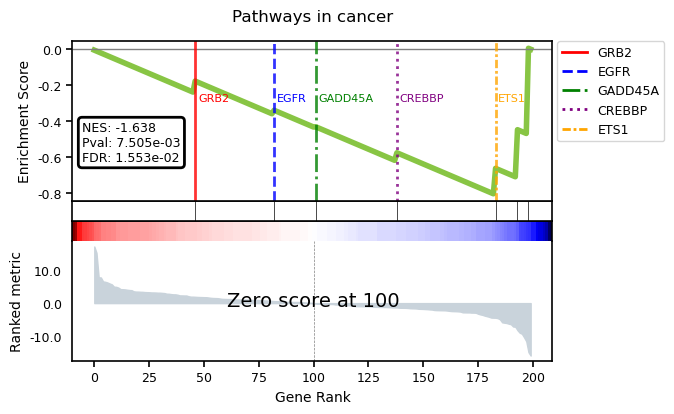

In [72]:
dap.plot_gsea_with_genes(

    # =========================
    # Data
    # =========================
    ranking= res_gsea.ranking,
    res= res_gsea.results['Pathways in cancer'],
    term= 'Pathways in cancer',

    # =========================
    # Highlight genes
    # =========================
    genes=gene_styles,
    gene_sets=None,
    show_lines=True,
    show_gene_labels=True,
    show_legend=True,

    # =========================
    # Gene lines
    # =========================
    default_line_color="blue",
    default_line_style="--",
    default_line_width=2,
    default_line_alpha=0.8,

    # =========================
    # Gene labels
    # =========================
    gene_label_rotation=0,
    gene_label_color="black",
    sync_label_color_with_line=True,
    gene_label_size=8,
    gene_label_offset_pts=2,
    gene_label_y=-0.3,
    gene_label_va="bottom",
    default_label_alpha=1.0,
    default_label_weight="normal",
    default_label_style="normal",

    # =========================
    # Stats
    # =========================
    show_stats=True,
    show_NES=True,
    show_pval=True,
    show_FDR=True,
    stats_text_size=9,
    stats_box=True,
    stats_box_edgecolor="black",
    stats_box_facecolor="white",
    stats_box_linewidth=2,
    stats_box_alpha=0.8,
    stats_x=0.02,
    stats_y=0.5,
    stats_ha="left",
    stats_va="top",

    # =========================
    # Title
    # =========================
    show_title=True,
    title_text=None,
    title_size=12,
    title_bold=False,

    # =========================
    # Axis labels
    # =========================
    show_es_ylabel=True,
    es_ylabel=None,
    es_ylabel_size=10,
    es_ylabel_weight="normal",

    show_rank_ylabel=True,
    rank_ylabel=None,
    rank_ylabel_size=10,
    rank_ylabel_weight="normal",

    show_rank_xlabel=True,
    rank_xlabel=None,
    rank_xlabel_size=10,
    rank_xlabel_weight="normal",

    # =========================
    # Ticks
    # =========================
    show_es_ticks=True,
    show_rank_ticks=True,
    es_tick_label_size=9,
    rank_tick_label_size=9,
    tick_width=1.2,
    tick_length=4,

    # =========================
    # Spines
    # =========================
    visible_spines=("left", "bottom", "right", "top"),
    spine_linewidth=1.2,

    # =========================
    # Figure size
    # =========================
    figsize=(6, 4),

    # =========================
    # Figure saving
    # =========================
    save_path=None,
    dpi=600
)